In [36]:
import math

import matplotlib.pyplot as plt
import pandas as pd

In [73]:
CLIP_VAL = 7.192

df = pd.read_csv("results/preds_hybrid_conf_2026-09-02T15_45_53_rep1.csv")  # w_anchor=0.92
# df = pd.read_csv("results/preds_hybrid_conf_2026-09-02T15_48_17_rep1.csv") # w_anchor=0.91
# df = pd.read_csv("results/preds_hybrid_conf_2026-09-02T15_39_58_rep1.csv") # w_anchor=0.90
print(df.shape)

(148, 10)


In [74]:
df.head()

,mu0,mu1,y0_mean,y1_mean,y0_std,y1_std,y0_lo95,y0_hi95,y1_lo95,y1_hi95
0,-0.741982,1.022022,-0.469447,1.066023,3.176000,1.585964,-6.848902,5.325758,-0.485624,6.084671
1,-0.352879,1.173856,-0.669629,1.243261,2.859901,1.371175,-6.868946,4.995450,-0.564879,4.604005
2,-0.820336,0.983238,-0.144531,1.058991,2.370213,1.033243,-5.678316,3.963510,-0.174333,2.429952
3,-0.502919,1.121752,-1.075287,0.844779,2.890390,0.721613,-6.751724,6.388587,-0.669700,2.641323
4,-0.987506,0.885718,-0.287928,1.071085,2.891349,1.006251,-6.779798,6.275544,-0.665484,4.175178


In [75]:
df.describe()

,mu0,mu1,y0_mean,y1_mean,y0_std,y1_std,y0_lo95,y0_hi95,y1_lo95,y1_hi95
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,-0.456661,1.093815,-0.850437,1.132108,2.860442,1.242037,-6.662298,4.741742,-0.405482,4.562465
std,0.628009,0.182739,0.427649,0.176573,0.337037,0.279692,0.575065,1.297457,0.272706,1.278090
min,-1.147673,0.763769,-1.873567,0.800337,1.945176,0.581248,-7.191954,1.422486,-1.546841,2.051510
25%,-0.870080,0.956562,-1.144089,1.000924,2.670366,1.038814,-7.073731,3.880257,-0.574769,3.628014
50%,-0.617763,1.076854,-0.837743,1.114488,2.890223,1.262999,-6.852647,4.882069,-0.380011,4.691670
75%,-0.231622,1.211606,-0.567118,1.259045,3.063792,1.474947,-6.426147,5.804225,-0.215753,5.519610
max,2.715451,1.680429,0.243213,1.579931,3.706219,1.902800,-4.273190,6.883940,0.152823,6.948247


In [76]:
print("Rows with y0_lo95 equal to its minimum:", sum(df["y0_lo95"] == df["y0_lo95"].min()))
print("Rows with y0_hi95 equal to its maximum:", sum(df["y0_hi95"] == df["y0_hi95"].max()))
print()
print("Rows with y1_lo95 equal to its minimum:", sum(df["y1_lo95"] == df["y1_lo95"].min()))
print("Rows with y1_hi95 equal to its maximum:", sum(df["y1_hi95"] == df["y1_hi95"].max()))

Rows with y0_lo95 equal to its minimum: 1
Rows with y0_hi95 equal to its maximum: 1

Rows with y1_lo95 equal to its minimum: 1
Rows with y1_hi95 equal to its maximum: 1


Number of bins: 13


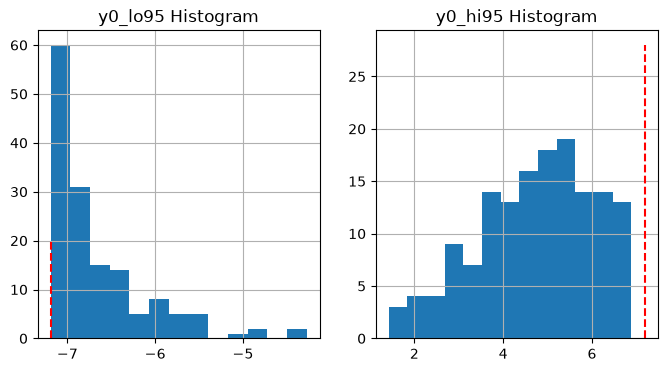

In [77]:
num_bins = math.ceil(math.sqrt(len(df)))
print(f"Number of bins: {num_bins}")

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

fig.sca(axs[0])
df["y0_lo95"].hist(bins=round(num_bins))
plt.vlines(-CLIP_VAL, 0, 20, colors="red", linestyles="dashed", label="clip lower bound")
axs[0].set_title("y0_lo95 Histogram")

fig.sca(axs[1])
df["y0_hi95"].hist(bins=round(num_bins))
xmin, xmax = axs[1].get_xlim()
plt.vlines(CLIP_VAL, 0, 28, colors="red", linestyles="dashed", label="clip lower bound")
axs[1].set_title("y0_hi95 Histogram")

plt.show()

In [78]:
df.nsmallest(10, "y0_lo95")["y0_lo95"]

42    -7.191954
106   -7.183858
27    -7.182619
83    -7.180173
55    -7.178961
5     -7.176269
31    -7.174242
114   -7.174184
133   -7.173022
86    -7.171042
Name: y0_lo95, dtype: float64

In [79]:
df.nlargest(10, "y0_hi95")["y0_hi95"]

64     6.883940
147    6.833961
14     6.799652
38     6.747215
53     6.739380
144    6.694862
61     6.663963
139    6.662269
16     6.577817
74     6.573907
Name: y0_hi95, dtype: float64